# Prueba Microcredencial Gestión de Carteras con Python
20/04/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import missingno as mso
import cvxpy as cp
import statsmodels.api as sm
from pandas_datareader import data as pdr
from scipy.linalg import sqrtm

## Preparación de datos
Descarga de datos

In [26]:
tickers = [
    "AAPL",  # Apple Inc. (Tecnología)
    "BTC-USD",  # Bitcoin (Activo de riesgo/liquidez global)
    "GLD",  # SPDR Gold Shares (Oro, refugio de valor)
    "DE",  # Deere & Co (Líder en tecnología agrícola y maquinaria)
    "UNP",  # Union Pacific (Ferrocarriles, columna vertebral logística de EE.UU.)
    "LIN",  # Linde plc (Gases industriales, esencial para la producción global)
    "SHW",  # Sherwin-Williams (Construcción y mercado inmobiliario)
    "COST",  # Costco Wholesale (Consumo masivo y modelo de suscripción)
    "TJX",  # TJX Companies (Retail de descuento, fuerte en ciclos de inflación)
    "LULU",  # Lululemon Athletica (Consumo discrecional premium y estilo de vida)
    "UNH",  # UnitedHealth Group (Servicios y seguros de salud, pilar financiero)
    "ISRG",  # Intuitive Surgical (Vanguardia en cirugía robótica)
    "SYK",  # Stryker Corp (Equipamiento médico y envejecimiento poblacional)
    "NEE",  # NextEra Energy (Líder en utilidades renovables y transición energética)
    "AMT",  # American Tower (REIT de infraestructura para telecomunicaciones/5G)
    "SPGI",  # S&P Global (Calificaciones crediticias y dueños de índices)
    "V",  # Visa (Red global de pagos y digitalización del efectivo)
    "ICE",  # Intercontinental Exchange (Infraestructura de mercados y dueños del NYSE)
]
data = yf.download(tickers, start="2016-01-01", end="2026-04-15", auto_adjust=True)["Close"]

[*********************100%***********************]  18 of 18 completed


In [27]:
data_idx = yf.download("SPY", start=data.index.min(), end=data.index.max(), auto_adjust=True)["Close"]


[*********************100%***********************]  1 of 1 completed


Limpieza

In [28]:
# TODO
data = data.dropna(axis = 1, how = "all")
data = data.dropna(axis = 0, how = "any")

data_idx = data_idx.dropna(axis = 1, how = "all")
data_idx = data_idx.dropna(axis = 0, how = "any")

ret_data = np.log(data).diff().dropna()
ret_idx = np.log(data_idx).diff().dropna()


import missingno as msno


Alineamos los dataframes de precios de los activos con el del índice.

In [30]:
# TODO

data , data_idx = data.align(data_idx, axis = 0, join = "inner")

## Cálculo de carteras

Crea una función llamada `cartera_min_vol` que calcule la cartera de mínima volatilidad.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
* Resultado:
    * Vector de pesos de la cartera.

In [31]:
# TODO
def cartera_min_vol(ret):


    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()


        pesos = cp.Variable(num_act)


        restricciones = [pesos >= 0,cp.sum(pesos) == 1,]

        riesgo = cp.quad_form(pesos, matriz_cov)
        objective = cp.Minimize(riesgo)


        prob = cp.Problem(objective, restricciones)
        resultado = prob.solve()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0 for x in pesos.value])

        return pesos_ajustados

    else:
      return None



Crea una función llamada `cartera_max_sharpe` que calcule la cartera de máximo ratio de Sharpe.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
    * Tasa libre de riesgo.
* Resultado:
    * Vector de pesos de la cartera.

In [32]:
# TODO

def cartera_max_sharpe(ret, ret_rf):

    if isinstance(ret, pd.DataFrame):

        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean()

        x = cp.Variable(num_act)
        riesgo = cp.quad_form(x, matriz_cov)

        pi = np.array(retornos_esperados - ret_rf)


        restricciones = [pi @ x ==1, x>=0]

        objective = cp.Minimize(riesgo)

        problema = cp.Problem(objective, restricciones)


        resultado  = problema.solve()

        pesos = x.value
        pesos /= pesos.sum()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0  for x in pesos])

        return pesos_ajustados

    else:
        return None


Crea una función llamada `cartera_risk_parity` que calcule la cartera Risk Parity.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
* Resultado:
    * Vector de pesos de la cartera.

In [33]:
# TODO
def cartera_risk_parity(ret):
    """
    Función que calcula la cartera de riesgo paridad para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de riesgo paridad"""

    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        b = 1 / num_act

        x = cp.Variable(num_act)
        gamma = cp.Variable(num_act, nonneg=True)
        psi = cp.Variable(nonneg=True)

        z = matriz_cov @ x

        obj = cp.pnorm(b**0.5 * psi - gamma, p=2)
        ret = retornos_esperados.T @ x

        constraints = [cp.sum(x) == 1, x >= 0, cp.SOC(psi, sqrtm(matriz_cov) @ x)]

        for i in range(num_act):
            constraints += [cp.SOC(x[i] + z[i], cp.vstack([2 * gamma[i], x[i] - z[i]]))]

        objective = cp.Minimize(obj * 1000)
        prob = cp.Problem(objective, constraints)
        prob.solve()

        pesos_ajustados = np.array([np.round(xi, 3) if xi > 10**-4 else 0 for xi in x.value])

        return pesos_ajustados

    else:
        return None


Crea una función llamada `cartera_min_cvar` que calcule la cartera de mínimo CVaR.

* Parámetros de entrada:
    * DataFrame de retornos de los activos.
    * Nivel de confianza para el cálculo del CVaR.
* Resultado:
    * Vector de pesos de la cartera.

In [34]:
# TODO

def cartera_min_cvar(ret):

  if isinstance(ret, pd.DataFrame):

    num_act = ret.shape[1]
    num_data = ret.shape[0]
    alpha = 0.05
    retornos_esperados = ret.mean().to_numpy()

    pesos = cp.Variable(num_act)
    t = cp.Variable()
    ui = cp.Variable(num_data)

    riesgo = t + cp.sum(ui) / (alpha * num_data)
    retornos = retornos_esperados.T @ pesos

    restricciones = [-ret @ pesos - t- ui <= 0,
                     ui >= 0,
                     cp.sum(pesos) == 1,
                     pesos >= 0]

    objective = cp.Minimize(riesgo)

    prob = cp.Problem(objective, restricciones)
    cvar95_min_cvar = prob.solve()

    pesos_ajustados_cvar = np.array([np.round(x, 3) if x > 10**-4 else 0  for x in pesos.value])

    return pesos_ajustados_cvar

  else:
    return None




## Rebalanceo de carteras

* Vamos a rebalancear las carteras el primer dia laborable de cada 2 meses.
* Para calcular los pesos de cada cartera vamos a utilizar todos los datos disponibles hasta el momento del rebalanceo.
* El primer rebalanceo se realizará el 01/02/2019.
* Suponemos que no hay costes de transacción.
* Para el cálculo del ratio de Sharpe utilizamos una tasa libre de riesgo del 0.0% anual.
* Para el cálculo del CVaR utilizamos un nivel de confianza del 95%.

In [102]:
# TODO
num_data , num_act = data.shape

num_act_max = num_act # 10, 12,15....

fecha_inicio = "2019-02-01"

rng = np.random.default_rng(seed=42)
indices_aleatorios = rng.choice(num_act, size=num_act_max, replace=False)

idx_inicio = data.index.get_loc(fecha_inicio)


precios_activos_select = data.iloc[:, indices_aleatorios]

periodo_rebalanceo = 21 * 2


Calculamos los retornos de cada una de las carteras a partir de los pesos y los retornos de los activos

In [103]:
# TODO
pesos_min_vol = {}
pesos_max_sharpe = {}
pesos_risk_parity = {}

for i in range(idx_inicio, len(precios_activos_select), periodo_rebalanceo):
    # print(f"Rebalanceando en la apertura del día {i}...")
    # Seleccionamos los precios disponibles para el rebalanceo (hasta los de cierre del día anterior al rebalanceo).
    precios_rebalanceo = precios_activos_select.iloc[i - idx_inicio : i]
    # Calculamos los rendimientos logarítmicos para el período de look_back.
    ret_rebalanceo = np.log(precios_rebalanceo).diff().dropna()
    # Obtenemos la fecha en la que hacemos el rebalanceo y, por tanto, desde la que son válidos los pesos calculados.
    fecha = precios_activos_select.index[i]
    # Calculamos los pesos de cada cartera y los guardamos en un diccionario con la fecha como clave.
    pesos_min_vol[fecha] = cartera_min_vol(ret_rebalanceo)
    pesos_max_sharpe[fecha] = cartera_max_sharpe(ret_rebalanceo, ret_rf=0.01 / 252)
    pesos_risk_parity[fecha] = cartera_risk_parity(ret_rebalanceo)

# Convertimos los diccionarios de pesos en DataFrames para facilitar su uso posterior.
pesos_min_vol_df = pd.DataFrame(pesos_min_vol).T
pesos_min_vol_df.columns = precios_activos_select.columns
pesos_max_sharpe_df = pd.DataFrame(pesos_max_sharpe).T
pesos_max_sharpe_df.columns = precios_activos_select.columns
pesos_risk_parity_df = pd.DataFrame(pesos_risk_parity).T
pesos_risk_parity_df.columns = precios_activos_select.columns

Graficamos la evolución de cada una de las carteras y del índice para comparar su desempeño a lo largo del tiempo, puponiendo que invertimos 1 dólar al inicio del período.

In [104]:
# TODO
px = precios_activos_select.iloc[precios_activos_select.index.get_loc(pesos_min_vol_df.index[0]) - 1 :, :]
retornos_activos_select = np.log(px).diff().dropna()
retornos_indice = np.log(data_idx.loc[px.index]).diff().dropna()

In [105]:
pesos_min_vol_daily_df = pesos_min_vol_df.reindex(index=retornos_activos_select.index, method="ffill")
pesos_max_sharpe_daily_df = pesos_max_sharpe_df.reindex(index=retornos_activos_select.index, method="ffill")
pesos_risk_parity_daily_df = pesos_risk_parity_df.reindex(index=retornos_activos_select.index, method="ffill")

In [106]:
retornos_min_vol = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_min_vol_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["min_vol"],
)
retornos_max_sharpe = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_max_sharpe_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["max_sharpe"],
)
retornos_risk_parity = pd.DataFrame(
    np.matrix(retornos_activos_select.values @ pesos_risk_parity_daily_df.values.T).diagonal().T,
    index=retornos_activos_select.index,
    columns=["risk_parity"],
)

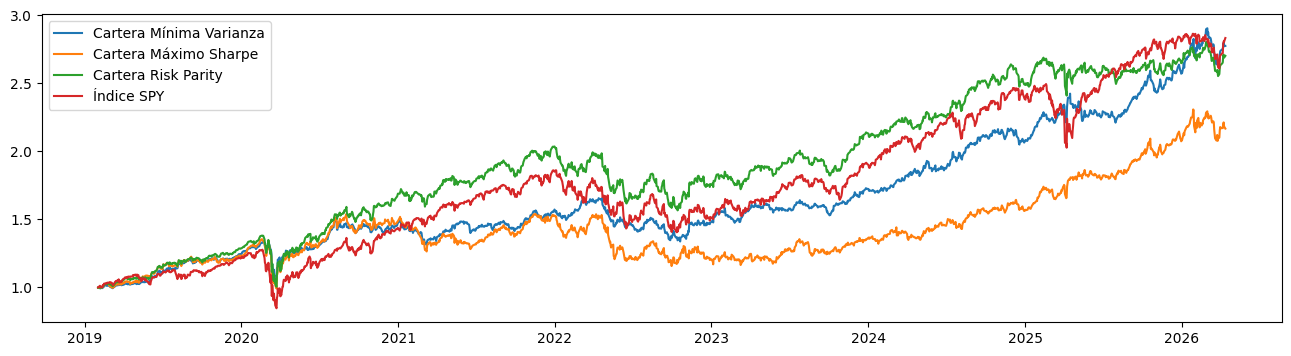

In [107]:
plt.figure(figsize=(16, 4))
plt.plot(np.exp(retornos_min_vol.cumsum()), label="Cartera Mínima Varianza")
plt.plot(np.exp(retornos_max_sharpe.cumsum()), label="Cartera Máximo Sharpe")
plt.plot(np.exp(retornos_risk_parity.cumsum()), label="Cartera Risk Parity")
plt.plot(np.exp(retornos_indice.cumsum()), label="Índice SPY")
plt.legend()
plt.show()